# Sign Language MNIST - CNN Model Training

This notebook trains a CNN to recognize ASL letters from the Sign Language MNIST dataset.

## 1. Install and Import Required Libraries

In [2]:
%pip install -q tensorflow pandas numpy matplotlib scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import os
import warnings
warnings.filterwarnings('ignore')

print('TensorFlow version:', tf.__version__)


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
TensorFlow version: 2.21.0


## 2. Load and Explore the Dataset

In [3]:
# Load training and test datasets
train_data = pd.read_csv('sign_mnist_train/sign_mnist_train.csv')
test_data = pd.read_csv('sign_mnist_test/sign_mnist_test.csv')

print(f'Training data shape: {train_data.shape}')
print(f'Test data shape: {test_data.shape}')
print(f'\nFirst few rows:')
print(train_data.head())
print(f'\nLabel distribution in training data:')
print(train_data['label'].value_counts().sort_index())

Training data shape: (27455, 785)
Test data shape: (7172, 785)

First few rows:
   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      3     107     118     127     134     139     143     146     150   
1      6     155     157     156     156     156     157     156     158   
2      2     187     188     188     187     187     186     187     188   
3      2     211     211     212     212     211     210     211     210   
4     13     164     167     170     172     176     179     180     184   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0     153  ...       207       207       207       207       206       206   
1     158  ...        69       149       128        87        94       163   
2     187  ...       202       201       200       199       198       199   
3     210  ...       235       234       233       231       230       226   
4     185  ...        92       105       105       108       133       16

## 3. Preprocess the Data

In [4]:
# Extract labels and pixel data
y_train = train_data['label'].values
X_train = train_data.drop('label', axis=1).values / 255.0  # Normalize to [0, 1]

y_test = test_data['label'].values
X_test = test_data.drop('label', axis=1).values / 255.0

# Reshape to (num_samples, 28, 28, 1) for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# One-hot encode labels (26 letters: A-Z)
num_classes = 26
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

print(f'Preprocessed training data shape: {X_train.shape}')
print(f'One-hot encoded labels shape: {y_train_cat.shape}')
print(f'Data range: [{X_train.min()}, {X_train.max()}]')

Preprocessed training data shape: (27455, 28, 28, 1)
One-hot encoded labels shape: (27455, 26)
Data range: [0.0, 1.0]


## 4. Visualize Some Training Examples

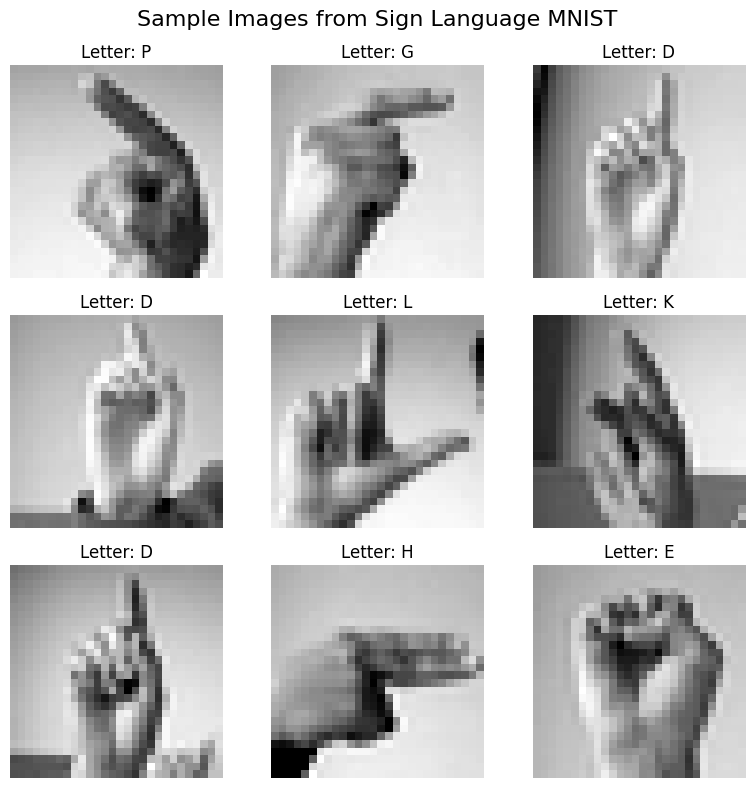

In [5]:
# Map labels to letters
label_to_letter = {i: chr(65 + i) for i in range(26)}  # A=0, B=1, ..., Z=25

# Display 9 random training images
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
fig.suptitle('Sample Images from Sign Language MNIST', fontsize=16)

for i, ax in enumerate(axes.flat):
    idx = np.random.randint(0, X_train.shape[0])
    image = X_train[idx].reshape(28, 28)
    label = label_to_letter[y_train[idx]]
    
    ax.imshow(image, cmap='gray')
    ax.set_title(f'Letter: {label}')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 5. Build and Train the CNN Model

In [6]:
# Build CNN model
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1), padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(26, activation='softmax')  # 26 classes for A-Z
])

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         6,682 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 394,522 (1.50 MB)

 Trainable params: 394,522 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train the model
history = model.fit(
    X_train, y_train_cat,
    batch_size=128,
    epochs=15,
    validation_split=0.2,
    verbose=1
)

Epoch 1/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.1992 - loss: 2.6474 - val_accuracy: 0.7512 - val_loss: 0.9904
Epoch 2/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.7105 - loss: 0.8525 - val_accuracy: 0.9421 - val_loss: 0.2633
Epoch 3/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8624 - loss: 0.3954 - val_accuracy: 0.9869 - val_loss: 0.0873
Epoch 4/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9214 - loss: 0.2318 - val_accuracy: 0.9949 - val_loss: 0.0309
Epoch 5/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9503 - loss: 0.1486 - val_accuracy: 0.9960 - val_loss: 0.0240
Epoch 6/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9635 - loss: 0.1098 - val_accuracy: 1.0000 - val_loss: 0.0062
Epoch 7/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9745 - loss: 0.0808 - val_accuracy: 0.9998 - val_loss: 0.0042
Epoch 8/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9790 - loss: 0.0653 - val_accu

## 6. Evaluate the Model

Test Loss: 0.1013
Test Accuracy: 0.9700 (97.00%)


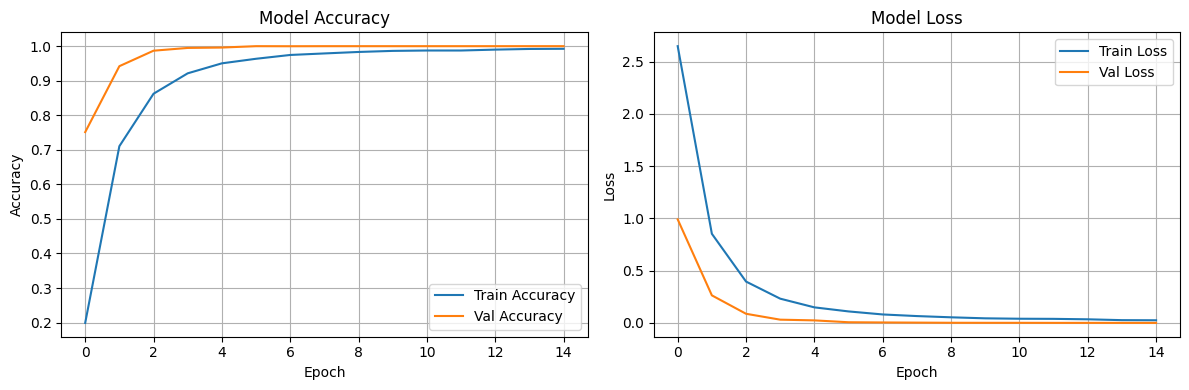

In [8]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 7. Save the Model

In [ ]:
# Save as H5 format
model.save('sign_language_model.h5')
print('Model saved as sign_language_model.h5')

# Also save as Keras native format
model.save('sign_language_model.keras')
print('Model saved as sign_language_model.keras')

Model saved as sign_language_model.h5


ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=sign_language_model_tf.

## 8. Test Predictions on Sample Images

In [ ]:
# Make predictions on test set
predictions = model.predict(X_test[:9])
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test_cat[:9], axis=1)

# Visualize predictions
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle('Model Predictions on Test Set', fontsize=16)

for i, ax in enumerate(axes.flat):
    image = X_test[i].reshape(28, 28)
    true_label = label_to_letter[true_labels[i]]
    pred_label = label_to_letter[predicted_labels[i]]
    confidence = predictions[i][predicted_labels[i]]
    
    ax.imshow(image, cmap='gray')
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label} ({confidence:.2f})', color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 9. Integration Helper - Function to Use Model in Real-Time

In [ ]:
def preprocess_image_for_model(image_array, target_size=(28, 28)):
    """
    Preprocess an image for the sign language model.
    
    Args:
        image_array: numpy array of the image
        target_size: size to resize to (default 28x28)
    
    Returns:
        preprocessed image ready for model input
    """
    import cv2
    
    # Convert to grayscale if needed
    if len(image_array.shape) == 3:
        gray = cv2.cvtColor(image_array, cv2.COLOR_BGR2GRAY)
    else:
        gray = image_array
    
    # Resize to 28x28
    resized = cv2.resize(gray, target_size)
    
    # Normalize
    normalized = resized.astype('float32') / 255.0
    
    # Reshape for model input
    reshaped = normalized.reshape(1, 28, 28, 1)
    
    return reshaped

def predict_gesture(model, image_array):
    """
    Predict the gesture in an image.
    
    Args:
        model: trained keras model
        image_array: numpy array of the image
    
    Returns:
        tuple of (predicted_letter, confidence)
    """
    processed = preprocess_image_for_model(image_array)
    prediction = model.predict(processed, verbose=0)
    
    predicted_class = np.argmax(prediction[0])
    confidence = prediction[0][predicted_class]
    predicted_letter = label_to_letter[predicted_class]
    
    return predicted_letter, confidence

print('Helper functions created successfully!')
print('Use predict_gesture(model, image) to get predictions')